<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [5]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [6]:
## Write your code here
# 1. Identify and count the duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_count}")

# 2. Remove the duplicate rows in place
df.drop_duplicates(inplace=True)

# 3. Verify they are gone
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 10
Number of duplicate rows after removal: 0


### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [7]:
## Write your code here
# Count the number of missing values in the 'CodingActivities' column
missing_coding_activities = df['CodingActivities'].isnull().sum()

print(f"Number of missing values in 'CodingActivities': {missing_coding_activities}")

Number of missing values in 'CodingActivities': 10971


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [8]:
## Write your code here
# Impute missing values in 'CodingActivities' using forward-fill
df['CodingActivities'] = df['CodingActivities'].ffill()

# Verify that there are no more missing values left in this column
print(f"Missing values in 'CodingActivities' after forward-fill: {df['CodingActivities'].isnull().sum()}")

Missing values in 'CodingActivities' after forward-fill: 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [9]:
## Write your code here
# List out columns that contain compensation or salary information
comp_columns = [col for col in df.columns if 'comp' in col.lower() or 'salary' in col.lower()]

print("Compensation-related columns found in this dataset:")
print(comp_columns)

Compensation-related columns found in this dataset:
['CompTotal', 'AIComplex', 'ConvertedCompYearly']


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [10]:
## Write your code here
# 1. Handle missing values by dropping rows where ConvertedCompYearly is NaN
df = df.dropna(subset=['ConvertedCompYearly'])

# 2. Apply Min-Max Scaling
min_val = df['ConvertedCompYearly'].min()
max_val = df['ConvertedCompYearly'].max()

df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - min_val) / (max_val - min_val)

# 3. Verify the new column by displaying its minimum and maximum values (should be 0.0 and 1.0)
print("Min-Max Scaling verification:")
print(f"Minimum value: {df['ConvertedCompYearly_MinMax'].min()}")
print(f"Maximum value: {df['ConvertedCompYearly_MinMax'].max()}")

Min-Max Scaling verification:
Minimum value: 0.0
Maximum value: 1.0


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [11]:
## Write your code here
# 1. Calculate the mean and standard deviation of the column
mean_val = df['ConvertedCompYearly'].mean()
std_val = df['ConvertedCompYearly'].std()

# 2. Apply the Z-score formula
df['ConvertedCompYearly_Zscore'] = (df['ConvertedCompYearly'] - mean_val) / std_val

# 3. Verify the normalization (Mean should be approx 0, Std Dev should be approx 1)
print("Z-score Normalization verification:")
print(f"Calculated Mean: {round(df['ConvertedCompYearly_Zscore'].mean(), 4)}")
print(f"Calculated Standard Deviation: {round(df['ConvertedCompYearly_Zscore'].std(), 4)}")

Z-score Normalization verification:
Calculated Mean: 0.0
Calculated Standard Deviation: 1.0


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


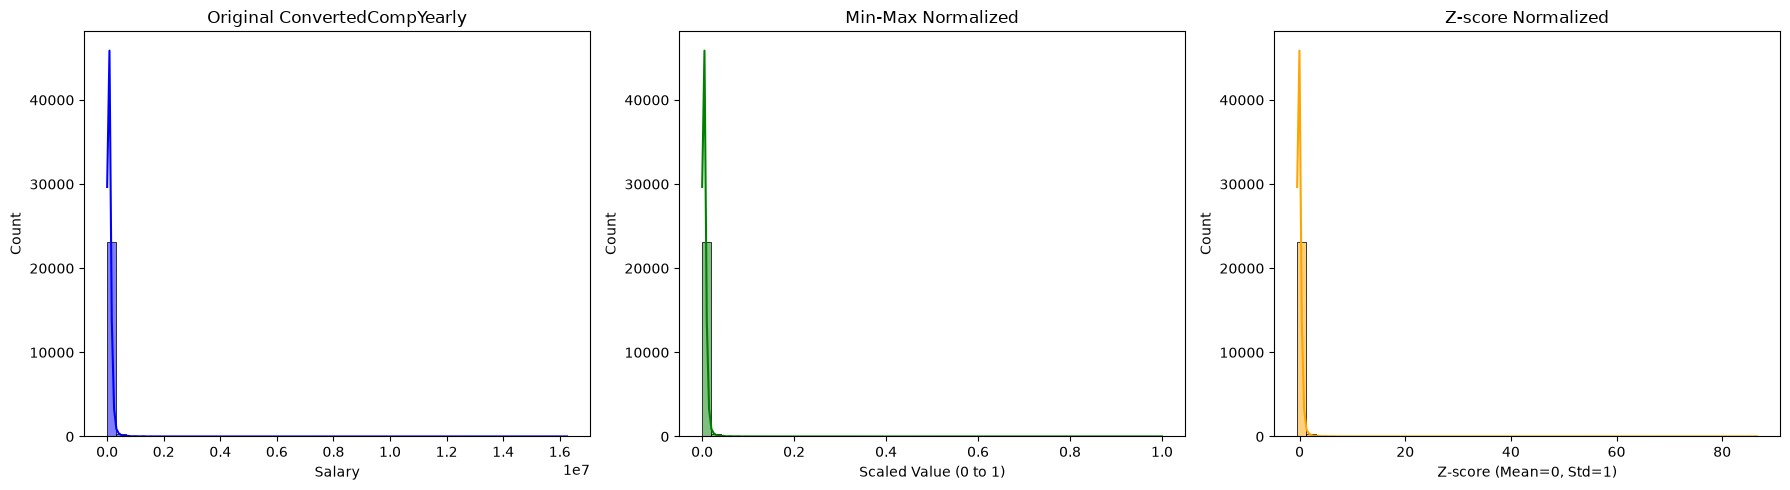

In [12]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Original Data
sns.histplot(df['ConvertedCompYearly'], bins=50, ax=axes[0], kde=True, color='blue')
axes[0].set_title('Original ConvertedCompYearly')
axes[0].set_xlabel('Salary')

# 2. Plot Min-Max Scaled Data
sns.histplot(df['ConvertedCompYearly_MinMax'], bins=50, ax=axes[1], kde=True, color='green')
axes[1].set_title('Min-Max Normalized')
axes[1].set_xlabel('Scaled Value (0 to 1)')

# 3. Plot Z-score Normalized Data
sns.histplot(df['ConvertedCompYearly_Zscore'], bins=50, ax=axes[2], kde=True, color='orange')
axes[2].set_title('Z-score Normalized')
axes[2].set_xlabel('Z-score (Mean=0, Std=1)')

plt.tight_layout()
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
